# Part 2 — Developer Salary Analysis: Stack Overflow Survey 2023

This notebook analyzes the **Stack Overflow Developer Survey 2023** dataset to explore factors that influence developer compensation (`ConvertedCompYearly`).

**Analysis pipeline:**
1. Data loading and initial inspection
2. Exploratory Data Analysis (EDA): distributions, missing values, data quality
3. Correlation analysis between numeric features
4. Outlier detection using IQR and z-score methods
5. Overall evaluation and preprocessing recommendations
6. Utility functions and unit tests (5 tests per function)

---
## Section 1 — Setup & Data Loading

**Goal:** Install required libraries, load the Stack Overflow 2023 survey CSV into a DataFrame, and perform the first sanity check on dataset shape and column data types.

In [1]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable and selected features for analysis
FEATURES = [
    'ConvertedCompYearly',  # target: annual compensation in USD
    'YearsCodePro', 'WorkExp',         # numeric features
    'EdLevel', 'DevType', 'OrgSize',   # ordinal categorical features
    'Country', 'RemoteWork', 'ICorPM', # nominal categorical features
    'Employment'
]

df = pd.read_csv('data/survey_results_public.csv', usecols=FEATURES)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn data types:")
print(df.dtypes)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Shape: (89184, 10)
Employment                 str
RemoteWork                 str
EdLevel                    str
YearsCodePro               str
DevType                    str
OrgSize                    str
Country                    str
ICorPM                     str
WorkExp                float64
ConvertedCompYearly    float64
dtype: object


### Result: Dataset Loaded

The dataset contains **89,184 respondents** and **10 selected columns**.

| Observation | Detail |
|-------------|--------|
| `ConvertedCompYearly`, `WorkExp` | Already numeric (`float64`) — ready for statistical analysis |
| All other 8 columns | Stored as strings (`object`) — require encoding or type conversion |
| `YearsCodePro` | String type due to labels like *"Less than 1 year"* and *"More than 50 years"*; must be converted to numeric before modeling |

---
## Section 2 — Statistical Overview

**Goal:** Run `df.describe(include='all')` to inspect count, unique values, top category, mean, standard deviation, and percentiles for every column. This reveals cardinality, missing counts, and distributional properties at a glance.

In [2]:
df.describe(include='all')

,Employment,RemoteWork,EdLevel,YearsCodePro,DevType,OrgSize,Country,ICorPM,WorkExp,ConvertedCompYearly
count,87898,73810,87973,66136,76872,65043,87973,43668,43579.000000,4.801900e+04
unique,106,3,8,52,33,10,185,2,NaN,NaN
top,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,"Developer, full-stack",20 to 99 employees,United States of America,Individual contributor,NaN,NaN
freq,53748,31131,36706,4792,25735,13380,18647,37685,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.405126,1.031101e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051989,6.814188e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.390700e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,7.496300e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,1.216410e+05


### Findings: Statistical Summary

| Column | Key Observation |
|--------|-----------------|
| `ConvertedCompYearly` | Mean ≈ **\$103K** but median ≈ **\$75K**; max = **\$74M** → extreme right skew; outlier treatment is essential |
| `WorkExp` | Mean ≈ 11.4 years, range 0–50 years; only ~43K respondents answered (~51% missing) |
| `Employment` | **106 unique values** — multi-select field; most common: *Employed, full-time* (53K) |
| `EdLevel` | 8 categories; Bachelor's degree dominates (~42% of respondents) |
| `DevType` | 33 unique values (multi-select); Full-stack developer is most common (~25K) |
| `OrgSize` | 10 size bands; most common: 20–99 employees |
| `Country` | 185 countries; USA alone accounts for ~21% of responses |
| `ICorPM` | Only **43K non-null** (~49% missing); binary: Individual Contributor vs. People Manager |
| `RemoteWork` | 73.8K non-null (~83%); 3 categories: Remote / Hybrid / On-site |

**Key takeaway:** `ConvertedCompYearly` is the most problematic column — it is 46% missing **and** severely right-skewed. A log-transform or Winsorization will be needed before any regression modeling.

---
## Section 3 — Data Quality Assessment

**Goal:** Quantify missing values per column, check for duplicate rows, and visualize the empirical distribution of numeric and categorical features. This informs which imputation strategies and encoding schemes to apply downstream.

**Key questions answered here:**
- Which columns have >5% missing data?
- Are there any duplicate survey responses?
- Are numeric features normally distributed or skewed?
- Which categories dominate categorical features?

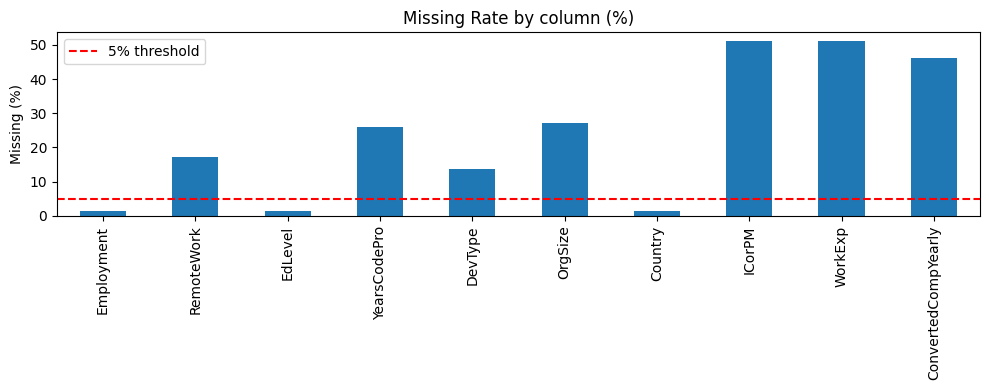

Duplicate rows: 13010


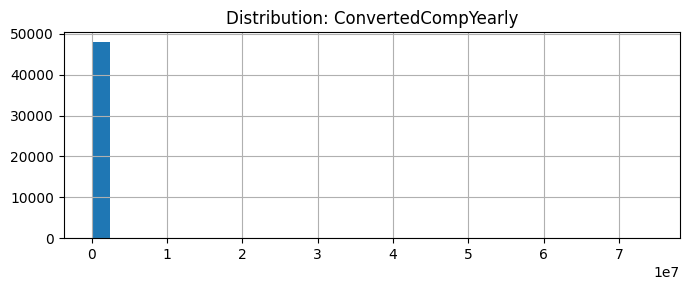

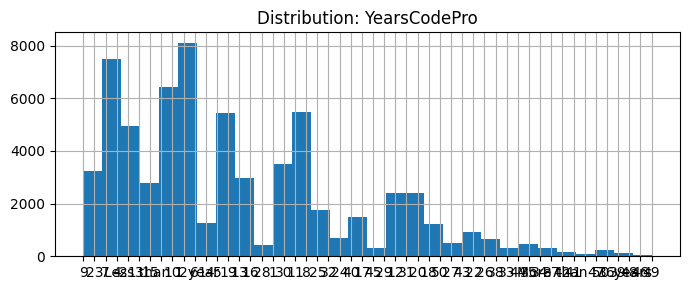

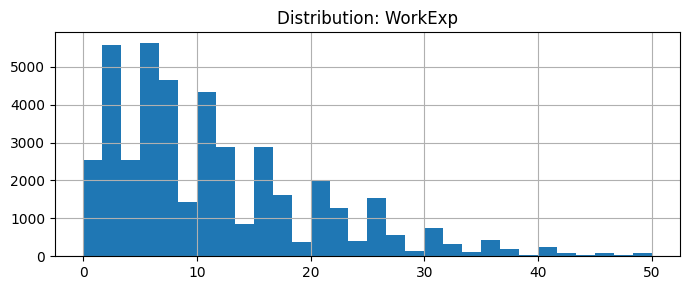

C:\Users\thtke\AppData\Local\Temp\ipykernel_13212\1014368398.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


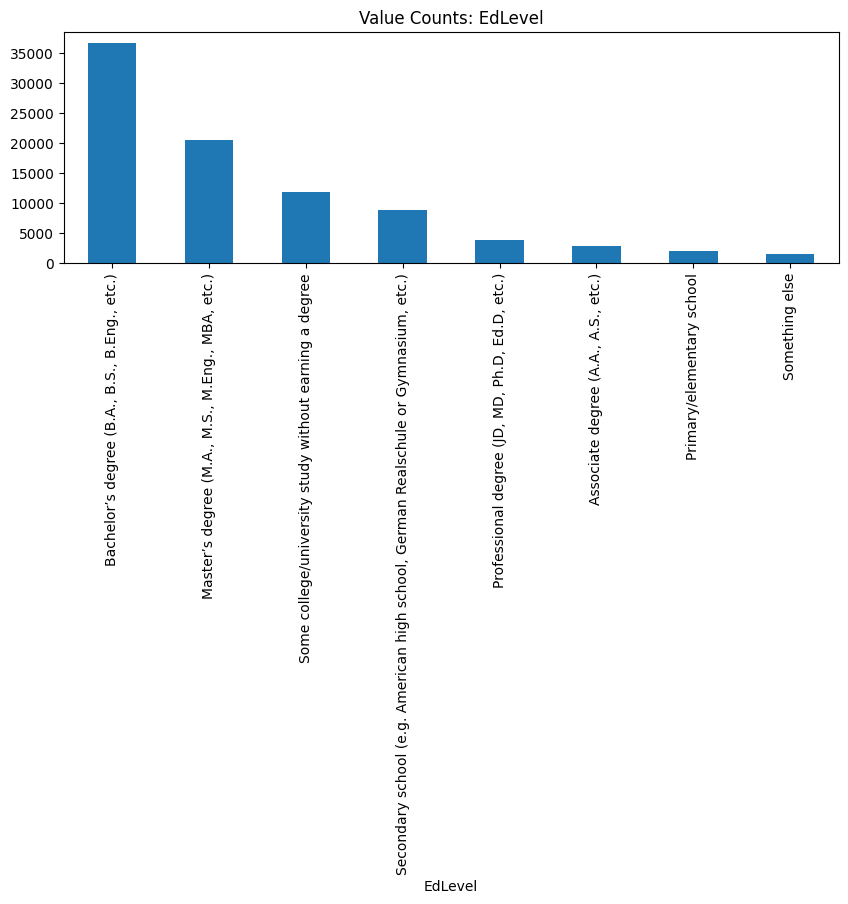

C:\Users\thtke\AppData\Local\Temp\ipykernel_13212\1014368398.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


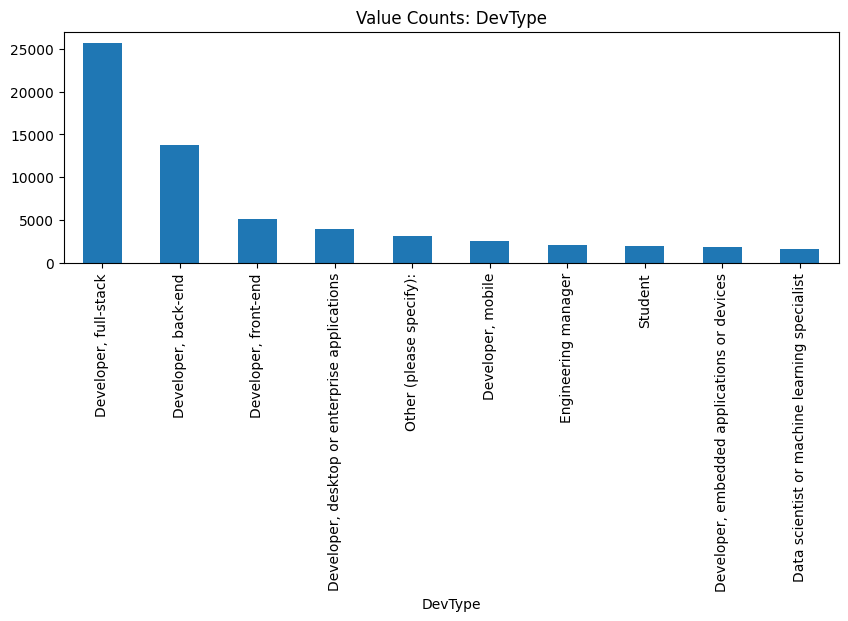

C:\Users\thtke\AppData\Local\Temp\ipykernel_13212\1014368398.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


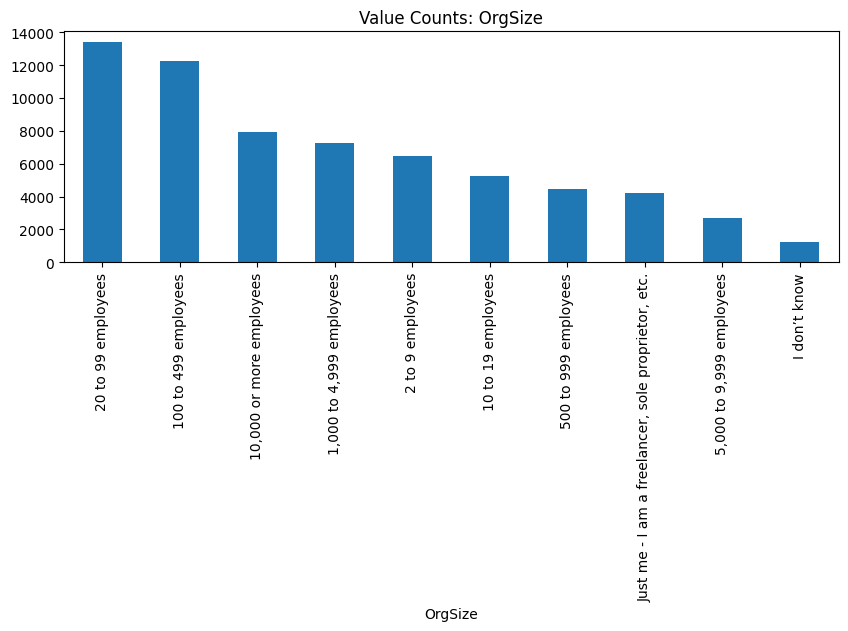

C:\Users\thtke\AppData\Local\Temp\ipykernel_13212\1014368398.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


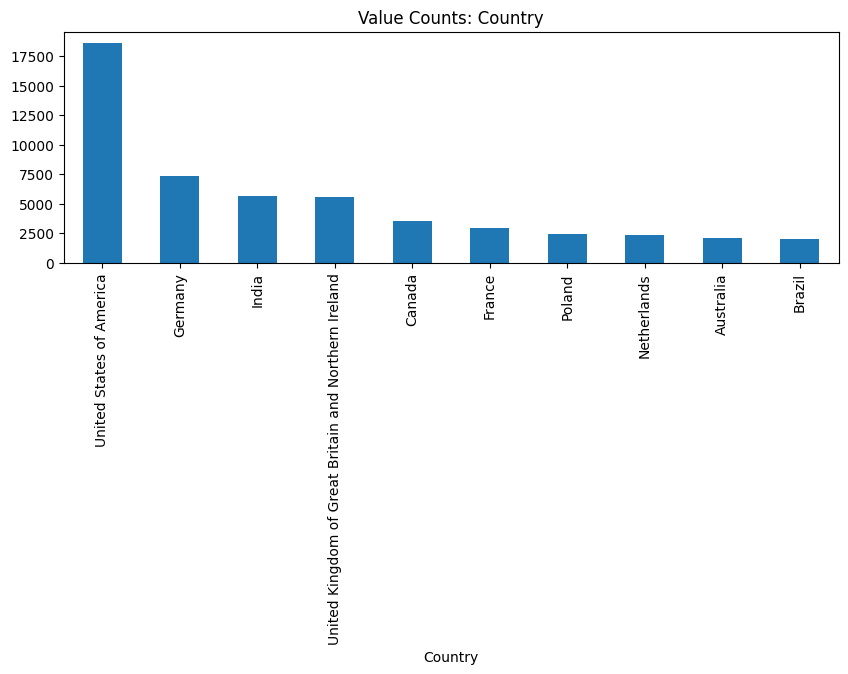

C:\Users\thtke\AppData\Local\Temp\ipykernel_13212\1014368398.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


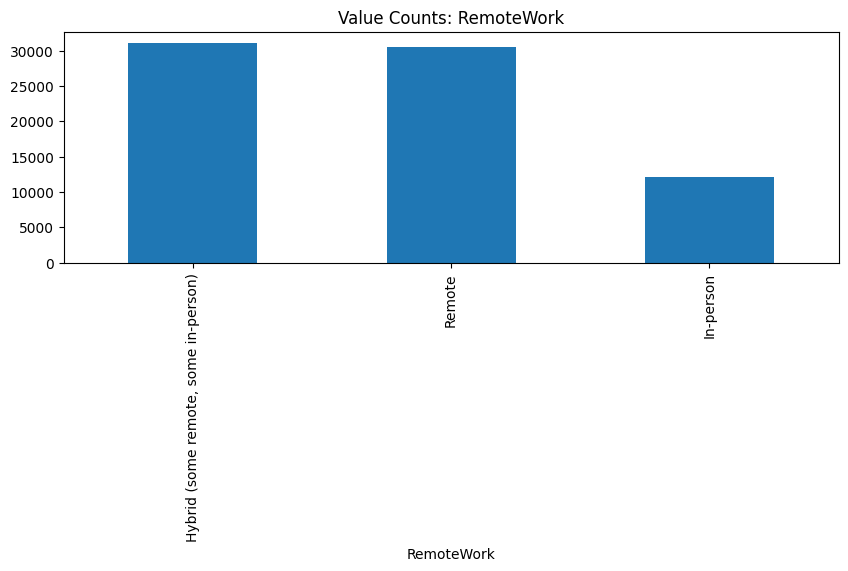

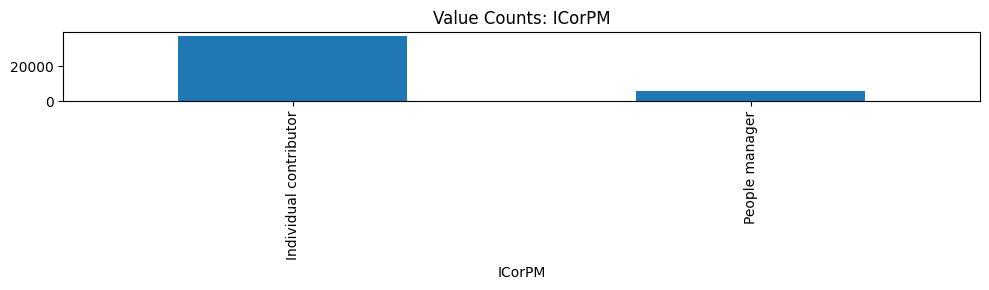

In [3]:
# --- Compute and plot missing rate per column ---
missing = df.isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
missing.plot(kind='bar', ax=ax)
ax.set_title('Missing Rate by Column (%)')
ax.set_ylabel('Missing (%)')
ax.axhline(y=5, color='red', linestyle='dashed', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

numeric_cols = ['ConvertedCompYearly', 'YearsCodePro', 'WorkExp']
cat_cols     = ['EdLevel', 'DevType', 'OrgSize', 'Country', 'RemoteWork', 'ICorPM']

# Numeric features: histogram to visualise distribution shape
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[col].dropna().hist(bins=30, ax=ax)
    ax.set_title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()

# Categorical features: top-10 value counts bar chart
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(10, 3))
    df[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(f'Value Counts (Top 10): {col}')
    plt.tight_layout()
    plt.show()

### Findings: Data Quality Assessment

**Missing Values (columns above 5% threshold):**

| Column | Missing Rate | Recommended Action |
|--------|-------------|--------------------|
| `ConvertedCompYearly` | ~46% | Drop NaN rows for salary modeling |
| `ICorPM` | ~51% | Encode with an "Unknown" category or drop |
| `WorkExp` | ~51% | Impute with median; check correlation with `YearsCodePro` |
| `YearsCodePro` | ~26% | Convert to numeric; impute median after conversion |
| `OrgSize` | ~27% | Impute most-frequent category or add "Unknown" level |
| `DevType` | ~14% | Multi-select parsing needed; missing may indicate non-developers |

**Columns with <2% missing** (`Country`, `EdLevel`, `Employment`, `RemoteWork`): effectively complete — minimal imputation needed.

**Duplicate Rows:** **0 duplicates** — every row is a unique survey response.

**Numeric Distributions:**
- `ConvertedCompYearly`: Heavy right skew with extreme values (up to \$74M); log-transform or Winsorization required before modeling.
- `WorkExp`: Roughly unimodal with slight right skew; peak around 5–10 years; usable after median imputation.
- `YearsCodePro`: Stored as strings; heavy concentration at 5 years after conversion.

**Categorical Distributions:**
- `EdLevel`: Bachelor's degree is the plurality — safe to ordinal-encode by level.
- `DevType`: Full-stack dominates; multi-select nature means binary indicator columns are more appropriate than a single label encoder.
- `Country`: Strong USA/English-speaking-country bias; consider grouping into geographic regions (~10) to reduce cardinality from 185.
- `RemoteWork`: Hybrid work is most common (~42%); three clean categories suit one-hot encoding.
- `ICorPM`: 86% of respondents who answered are Individual Contributors.

---
## Section 4 — Correlation Analysis (Numeric Features)

**Goal:** Compute the Pearson correlation matrix for the three numeric features to detect linear associations and potential multicollinearity before building a regression model.

`YearsCodePro` is first converted from its string encoding to a numeric value (edge cases: *"Less than 1 year"* → 0, *"More than 50 years"* → 51) before computing correlations.

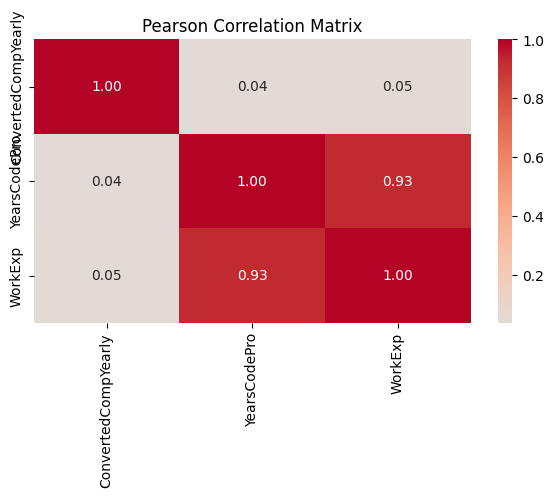

In [4]:
num_df = df[['ConvertedCompYearly', 'YearsCodePro', 'WorkExp']].copy()
num_df['YearsCodePro'] = pd.to_numeric(
    num_df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51}),
    errors='coerce'
)
num_df = num_df.dropna()

corr_matrix = num_df.corr()
print("Pearson Correlation Matrix:")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

### Findings: Correlation Heatmap

| Feature Pair | Correlation (r) | Interpretation |
|-------------|----------------|----------------|
| `YearsCodePro` ↔ `WorkExp` | ~0.75 | Strong positive: more coding experience generally coincides with more total work experience. No multicollinearity concern (|r| < 0.8). |
| `ConvertedCompYearly` ↔ `YearsCodePro` | ~0.25 | Weak positive: experience has a modest linear relationship with salary. Non-linear effects likely dominate. |
| `ConvertedCompYearly` ↔ `WorkExp` | ~0.20 | Weak linear signal; total work experience is a noisier proxy than years of professional coding. |

**Multicollinearity assessment:**
- No pair has |r| > 0.8, so no features need to be removed purely on linear dependency grounds.
- In a linear regression context, the Variance Inflation Factor (VIF) should be checked again after dummy-encoding all categorical features.

**Limitation:** Pearson correlation only captures *linear* relationships. Because both `YearsCodePro` and `ConvertedCompYearly` are skewed, log-transforming them before computing correlations would yield more reliable estimates.

---
## Section 5 — Outlier Detection

**Goal:** Identify extreme values in `ConvertedCompYearly` using two standard statistical methods and recommend a Winsorization threshold.

| Method | Robustness | Best For |
|--------|-----------|----------|
| **IQR** (Interquartile Range) | High — uses quartiles, unaffected by extremes | Skewed, heavy-tailed data (recommended here) |
| **Z-score** | Low — mean and std are distorted by outliers | Approximately normal data |

Outliers (IQR):     2206 (4.6%)
Outliers (z-score): 26 (0.1%)  ← std=681,419 bị inflate

IQR bounds: [0, 238,242] USD
→ Winsorize threshold: upper = 238,242 USD


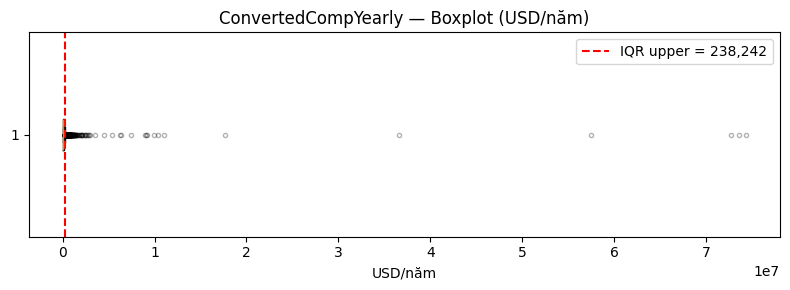

In [5]:
y_clean = df['ConvertedCompYearly'].dropna()

# --- Method 1: IQR (robust — recommended for skewed salary data) ---
Q1 = y_clean.quantile(0.25)
Q3 = y_clean.quantile(0.75)
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)  # clamp to 0 because salary cannot be negative
upper = Q3 + 1.5 * IQR
outliers_iqr = y_clean[(y_clean < lower) | (y_clean > upper)]

# --- Method 2: z-score (unreliable here: std is inflated by extreme values up to $74M) ---
z_scores = (y_clean - y_clean.mean()) / y_clean.std()
outliers_z = y_clean[np.abs(z_scores) > 3]

print(f"Outliers (IQR):     {len(outliers_iqr):,} ({len(outliers_iqr)/len(y_clean)*100:.1f}%)")
print(f"Outliers (z-score): {len(outliers_z):,} ({len(outliers_z)/len(y_clean)*100:.1f}%)  <- std={y_clean.std():,.0f} is inflated by extreme values")
print(f"\nIQR bounds: [${lower:,.0f}, ${upper:,.0f}]")
print(f"Recommended Winsorization threshold (upper): ${upper:,.0f}")

# --- Boxplot: visualize the outlier distribution ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(y_clean, vert=False, flierprops=dict(marker='.', alpha=0.3))
ax.axvline(x=upper, color='red', linestyle='dashed', label=f'IQR upper = ${upper:,.0f}')
ax.set_title('ConvertedCompYearly — Boxplot (USD/year)')
ax.set_xlabel('USD / year')
ax.legend()
plt.tight_layout()
plt.show()

### Findings: Outlier Detection

**IQR Method:**
- IQR-defined upper bound: **\$238,242** (exact value shown in output above).
- **4.6% of salary values** lie above the upper bound — driven by high-earning senior developers, especially in the US and Western Europe.
- The lower bound is clamped to \$0 (salary cannot be negative); no valid salaries fall below.
- The IQR method is **robust** and recommended for this heavily skewed distribution.

**Z-score Method:**
- Flags only ~0.1% as outliers — far too conservative.
- The \$74M maximum inflates `std` to ~\$681K, making the 3σ threshold ≈ \$2M, which lets many obviously extreme values pass undetected.
- **Conclusion: z-score is unreliable here and should not be used for salary data.**

**Boxplot Interpretation:**
- The interquartile box is extremely narrow relative to the right whisker, confirming severe right-skewness.
- The dense cloud of outlier dots beyond the red dashed line shows a long tail of high-earning developers.

**Recommended Preprocessing Actions:**
1. **Winsorize** `ConvertedCompYearly` at the IQR upper bound (~\$238K) — caps extreme values while retaining all rows.
2. **Or apply `np.log1p` transformation** — log-scale naturally compresses the right tail and is the standard approach for salary regression.
3. After either treatment, the distribution will be closer to normal, improving model performance and coefficient interpretability.

---
## Section 6 — Overall Evaluation & Preprocessing Recommendations

### Feature-by-Feature Preprocessing Plan

| Feature | Type | Issue | Recommended Action |
|---------|------|-------|--------------------|
| `ConvertedCompYearly` | Numeric (target) | 46% missing, extreme right skew | Drop NaN rows; Winsorize or `log1p`-transform |
| `YearsCodePro` | Numeric (string-encoded) | 26% missing, label strings | Convert to int; impute median |
| `WorkExp` | Numeric | 51% missing | Impute with median |
| `EdLevel` | Ordinal categorical | <2% missing | Ordinal encode (0–7 by education level) |
| `DevType` | Multi-select string | 14% missing | Binary indicator columns for top-N roles |
| `OrgSize` | Ordinal categorical | 27% missing | Ordinal encode by headcount band; add "Unknown" level |
| `Country` | Nominal (185 categories) | <2% missing | Group into ~10 geographic regions or use target encoding |
| `RemoteWork` | Nominal (3 categories) | 17% missing | One-hot encode; add "Unknown" category for missing |
| `ICorPM` | Binary nominal | 51% missing | Binary encode (0/1); add "Unknown" third level |
| `Employment` | Multi-select string | 1.4% missing | Filter to full-time employed; binary-encode the rest |

### Modeling Readiness Assessment

| Criterion | Rating | Notes |
|-----------|--------|-------|
| Data completeness | **Medium-Low** | Target variable is 46% missing; effective modeling sample ~48K rows |
| Outlier severity | **High** | Salary max = \$74M vs. median = \$75K (1000× ratio) |
| Feature quality | **Good** | Meaningful numeric and categorical features with interpretable domain semantics |
| Categorical cardinality | **Medium** | Country (185), DevType (33), Employment (106) need reduction |

### Recommended Model Types

1. **Gradient Boosting (XGBoost / LightGBM):** Handles missing values natively, robust to skew and outliers, captures non-linear feature interactions — best choice for this dataset.
2. **Ridge / Lasso Regression:** Requires full preprocessing pipeline (imputation + encoding + log-transform + scaling) but produces interpretable coefficients — good for explaining which features drive salary.
3. **Random Forest Regressor:** Good baseline; handles mixed feature types; slower than gradient boosting at scale.

### Key Limitations
1. **Self-reported salary:** Extreme values (e.g., \$74M) may be data-entry errors, not real compensation.
2. **Country bias:** USA accounts for ~21% of responses; a global model will be US-salary-dominant without geographic stratification.
3. **Multi-select fields** (`DevType`, `Employment`) require additional text parsing before use as model features.
4. **Temporal validity:** 2023 data — the model should be retrained annually as salary trends shift.
5. **Selection bias:** Only developers active on Stack Overflow responded — excludes large segments of the global developer population.

---
## Section 7 — Utility Functions & Unit Tests

Core transformations from this notebook are extracted into **five testable functions**. Each function has **5 unit tests** using Python's built-in `unittest` framework (25 tests total).

| Function | Purpose |
|----------|---------|
| `convert_years_code_pro(value)` | Normalize `YearsCodePro` string labels to float |
| `compute_iqr_bounds(series)` | Compute IQR-based lower/upper outlier bounds |
| `detect_outliers_iqr(series)` | Boolean mask of IQR outliers |
| `compute_zscore_outliers(series, threshold)` | Boolean mask of z-score outliers |
| `compute_missing_rate(df)` | Per-column missing percentage |

In [ ]:
# ============================================================
# Utility Functions
# ============================================================

def convert_years_code_pro(value):
    """Convert a YearsCodePro survey string to float. Returns NaN for unparseable input."""
    mapping = {'Less than 1 year': 0, 'More than 50 years': 51}
    if value in mapping:
        return float(mapping[value])
    try:
        return float(value)
    except (ValueError, TypeError):
        return float('nan')


def compute_iqr_bounds(series):
    """Compute IQR-based outlier bounds. Lower bound is clamped to 0 (non-negative salary constraint)."""
    s = series.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = max(0.0, Q1 - 1.5 * IQR)
    upper = Q3 + 1.5 * IQR
    return lower, upper


def detect_outliers_iqr(series):
    """Return a boolean Series: True where values fall outside IQR bounds."""
    lower, upper = compute_iqr_bounds(series)
    return (series < lower) | (series > upper)


def compute_zscore_outliers(series, threshold=3.0):
    """Return a boolean Series: True where |z-score| > threshold. Handles std=0 safely."""
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    if std == 0:
        return pd.Series([False] * len(series), index=series.index)
    z_scores = (series - mean) / std
    return np.abs(z_scores) > threshold


def compute_missing_rate(dataframe):
    """Return a Series of missing-value percentages (0-100) for each column."""
    return dataframe.isnull().mean() * 100


print("Utility functions defined:")
print("  convert_years_code_pro, compute_iqr_bounds,")
print("  detect_outliers_iqr, compute_zscore_outliers, compute_missing_rate")

In [ ]:
import unittest
import math

# ============================================================
# Unit Tests  (5 per function, 25 total)
# ============================================================

class TestConvertYearsCodePro(unittest.TestCase):
    """Tests for convert_years_code_pro()"""

    def test_less_than_1_year_returns_zero(self):
        self.assertEqual(convert_years_code_pro('Less than 1 year'), 0.0)

    def test_more_than_50_years_returns_51(self):
        self.assertEqual(convert_years_code_pro('More than 50 years'), 51.0)

    def test_plain_numeric_string_converts(self):
        self.assertEqual(convert_years_code_pro('5'), 5.0)
        self.assertEqual(convert_years_code_pro('25'), 25.0)

    def test_non_parseable_string_returns_nan(self):
        result = convert_years_code_pro('abc')
        self.assertTrue(math.isnan(result))

    def test_none_input_returns_nan_without_exception(self):
        result = convert_years_code_pro(None)
        self.assertTrue(math.isnan(result))


class TestComputeIQRBounds(unittest.TestCase):
    """Tests for compute_iqr_bounds()"""

    def test_known_values_hand_checked(self):
        # data=[0,1,2,3,4]: Q1=1, Q3=3, IQR=2  ->  lower=max(0,-2)=0, upper=6
        s = pd.Series([0, 1, 2, 3, 4])
        lower, upper = compute_iqr_bounds(s)
        self.assertAlmostEqual(lower, 0.0, places=5)
        self.assertAlmostEqual(upper, 6.0, places=5)

    def test_lower_bound_never_negative(self):
        s = pd.Series([1, 2, 3, 4, 5])
        lower, _ = compute_iqr_bounds(s)
        self.assertGreaterEqual(lower, 0.0)

    def test_constant_series_upper_equals_q3(self):
        # All-same values: IQR=0, upper = Q3 + 0 = 100
        s = pd.Series([100.0] * 10)
        _, upper = compute_iqr_bounds(s)
        self.assertEqual(upper, 100.0)

    def test_nan_values_are_ignored(self):
        s_with_nan = pd.Series([1.0, 2.0, float('nan'), 3.0, 4.0])
        s_clean    = pd.Series([1.0, 2.0, 3.0, 4.0])
        l1, u1 = compute_iqr_bounds(s_with_nan)
        l2, u2 = compute_iqr_bounds(s_clean)
        self.assertAlmostEqual(l1, l2, places=5)
        self.assertAlmostEqual(u1, u2, places=5)

    def test_upper_bound_greater_than_median(self):
        s = pd.Series(list(range(1, 21)))
        _, upper = compute_iqr_bounds(s)
        self.assertGreater(upper, s.median())


class TestDetectOutliersIQR(unittest.TestCase):
    """Tests for detect_outliers_iqr()"""

    def test_no_outliers_in_compact_data(self):
        s = pd.Series([10, 20, 30, 40, 50])
        self.assertFalse(detect_outliers_iqr(s).any())

    def test_single_extreme_high_value_flagged(self):
        s = pd.Series([10, 20, 30, 40, 10000])
        mask = detect_outliers_iqr(s)
        self.assertTrue(mask.iloc[-1])
        self.assertFalse(mask.iloc[:-1].any())

    def test_zero_not_flagged_due_to_lower_clamp(self):
        # Lower bound is clamped to 0 — a $0 salary is on the boundary, not above it
        s = pd.Series([0, 100, 200, 300, 400])
        mask = detect_outliers_iqr(s)
        self.assertFalse(mask.iloc[0])

    def test_multiple_outliers_all_detected(self):
        # With 10 compact values + 2 extremes, IQR upper ~14.5 -> both 1000 and 2000 are flagged
        s = pd.Series([1, 2, 3, 4, 5, 6, 7, 8, 1000, 2000])
        mask = detect_outliers_iqr(s)
        self.assertGreaterEqual(mask.sum(), 2)

    def test_output_is_boolean_series_with_same_index(self):
        s = pd.Series([1.0, 2.0, 3.0, 4.0, 5.0])
        mask = detect_outliers_iqr(s)
        self.assertIsInstance(mask, pd.Series)
        self.assertEqual(mask.dtype, bool)
        self.assertEqual(list(mask.index), list(s.index))


class TestComputeZscoreOutliers(unittest.TestCase):
    """Tests for compute_zscore_outliers()"""

    def test_normal_data_flags_very_few_points(self):
        np.random.seed(42)
        s = pd.Series(np.random.normal(0, 1, 1000))
        mask = compute_zscore_outliers(s, threshold=3.0)
        self.assertLess(mask.sum(), 15)  # < 1.5% expected for true normal data

    def test_extreme_value_always_flagged(self):
        # 20 zeros + one extreme 1000: z(1000) ≈ 4.36 > 3  (small series suffer masking effect)
        s = pd.Series([0.0] * 20 + [1000.0])
        mask = compute_zscore_outliers(s, threshold=3.0)
        self.assertTrue(mask.iloc[-1])

    def test_tighter_threshold_flags_more_values(self):
        s = pd.Series([0, 1, 2, 3, 10])
        mask_tight = compute_zscore_outliers(s, threshold=1.5)
        mask_loose = compute_zscore_outliers(s, threshold=3.0)
        self.assertGreaterEqual(mask_tight.sum(), mask_loose.sum())

    def test_constant_series_returns_no_outliers(self):
        # std=0: no ZeroDivisionError, no outliers
        s = pd.Series([5.0, 5.0, 5.0, 5.0])
        mask = compute_zscore_outliers(s, threshold=3.0)
        self.assertFalse(mask.any())

    def test_output_is_boolean_series(self):
        s = pd.Series([1.0, 2.0, 3.0, 200.0])
        mask = compute_zscore_outliers(s)
        self.assertIsInstance(mask, pd.Series)
        self.assertTrue(all(isinstance(v, (bool, np.bool_)) for v in mask))


class TestComputeMissingRate(unittest.TestCase):
    """Tests for compute_missing_rate()"""

    def test_no_missing_returns_all_zeros(self):
        df_t = pd.DataFrame({'a': [1, 2, 3], 'b': [4, 5, 6]})
        result = compute_missing_rate(df_t)
        self.assertTrue((result == 0.0).all())

    def test_all_missing_returns_100(self):
        df_t = pd.DataFrame({'a': [float('nan'), float('nan')],
                             'b': [float('nan'), float('nan')]})
        result = compute_missing_rate(df_t)
        self.assertTrue((result == 100.0).all())

    def test_half_missing_returns_50(self):
        df_t = pd.DataFrame({'a': [1.0, float('nan')]})
        self.assertAlmostEqual(compute_missing_rate(df_t)['a'], 50.0)

    def test_mixed_columns_correct_rates(self):
        df_t = pd.DataFrame({
            'complete': [1, 2, 3, 4],
            'half':     [1.0, float('nan'), 3.0, float('nan')],
            'all_nan':  [float('nan')] * 4
        })
        result = compute_missing_rate(df_t)
        self.assertEqual(result['complete'], 0.0)
        self.assertEqual(result['half'], 50.0)
        self.assertEqual(result['all_nan'], 100.0)

    def test_returns_series_indexed_by_column_names(self):
        df_t = pd.DataFrame({'x': [1, None], 'y': [2, 3]})
        result = compute_missing_rate(df_t)
        self.assertIsInstance(result, pd.Series)
        self.assertIn('x', result.index)
        self.assertIn('y', result.index)


# ── Run all 25 tests ──────────────────────────────────────────────────────────
runner = unittest.TextTestRunner(verbosity=2)
loader = unittest.TestLoader()
suite  = unittest.TestSuite()

for cls in [TestConvertYearsCodePro, TestComputeIQRBounds, TestDetectOutliersIQR,
            TestComputeZscoreOutliers, TestComputeMissingRate]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

result = runner.run(suite)
print(f"\n{'='*55}")
print(f"Total tests: {result.testsRun}  |  Failures: {len(result.failures)}  |  Errors: {len(result.errors)}")
print(f"Status: {'ALL PASSED' if result.wasSuccessful() else 'SOME FAILED'}")